In [10]:
import pandas as pd
import numpy as np
!pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("Warehouse.csv")
df.head (5)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [11]:
df.isnull().sum()

YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [12]:
df = df.dropna(subset=["RETAIL SALES"])


In [13]:
df.isnull().sum()

YEAR                  0
MONTH                 0
SUPPLIER            164
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          0
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [14]:
df["SUPPLIER"] = df["SUPPLIER"].fillna("Unknown")
df["ITEM TYPE"] = df["ITEM TYPE"].fillna("Unknown")


In [15]:
df.isnull().sum()

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64

In [16]:
df.head(10)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0
5,2020,1,KYSELA PERE ET FILS LTD,100641,CORTENOVA VENETO P/GRIG - 750ML,WINE,2.76,0.0,6.0
6,2020,1,SANTA MARGHERITA USA INC,100749,SANTA MARGHERITA P/GRIG ALTO - 375ML,WINE,0.08,1.0,1.0
7,2020,1,BROWN-FORMAN BEVERAGES WORLDWIDE,1008,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...,BEER,0.00,0.0,2.0
8,2020,1,JIM BEAM BRANDS CO,10103,KNOB CREEK BOURBON 9YR - 100P - 375ML,LIQUOR,6.41,4.0,0.0
9,2020,1,INTERNATIONAL CELLARS LLC,101117,KSARA CAB - 750ML,WINE,0.33,1.0,2.0


In [17]:
df.size

2768778

In [18]:
df.shape

(307642, 9)

In [19]:
df = df.drop_duplicates().dropna()
df = df.sort_values(by=["YEAR", "MONTH"])

In [20]:
df["RETAIL_SALES_LAG_1"] = df["RETAIL SALES"].shift(1)
df["RETAIL_SALES_LAG_12"] = df["RETAIL SALES"].shift(12)
df = df.dropna()
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,RETAIL_SALES_LAG_1,RETAIL_SALES_LAG_12
34833,2017,6,AMERICAN FIDELITY TRADING,101117,KSARA CAB - 750ML,WINE,0.00,0.0,1.0,5.40,0.00
34834,2017,6,HEAVEN HILL DISTILLERIES INC,10120,J W DANT BOURBON 100P - 1.75L,LIQUOR,1.84,1.0,0.0,0.00,0.00
34835,2017,6,BACCHUS IMPORTERS LTD,101257,NEIL ELLIS SINCERELY S/BLC - 750ML,WINE,0.00,0.0,1.0,1.84,0.00
34836,2017,6,LANTERNA DISTRIBUTORS INC,101370,SCHLINK HAUS SPATLESE - 750ML,WINE,0.00,0.0,1.0,0.00,0.00
34837,2017,6,PUNTO VINO LLC,119245,SALVANO BARBSCO - 750ML,WINE,0.00,0.0,1.0,0.00,0.08


Random Forest Results
MAE: 1.7089336240124238
MSE: 54.58617678190354
R² : 0.9396463269203092


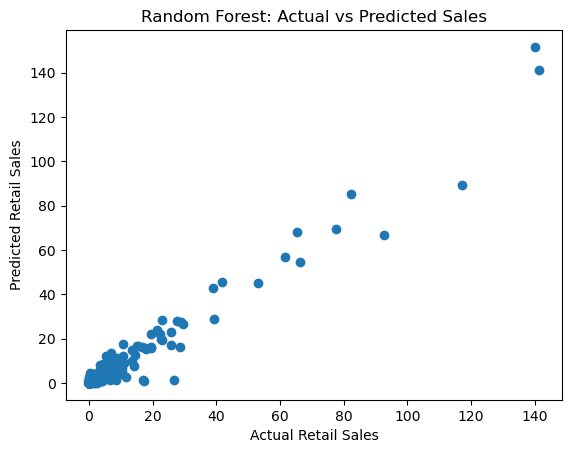

In [21]:
features = [
    "YEAR",
    "MONTH",
    "WAREHOUSE SALES",
    "RETAIL TRANSFERS",
    "RETAIL_SALES_LAG_1",
    "RETAIL_SALES_LAG_12"
]

X = df[features]
y = df["RETAIL SALES"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("MAE:", mae)
print("MSE:", mse)
print("R² :", r2)

# Visualizing
plt.figure()
plt.scatter(y_test[:300], y_pred[:300])
plt.xlabel("Actual Retail Sales")
plt.ylabel("Predicted Retail Sales")
plt.title("Random Forest: Actual vs Predicted Sales")
plt.show()

Linear Regression Results
MAE: 1.7081362967829563
MSE: 49.36308505616022
R² : 0.9454212829451696


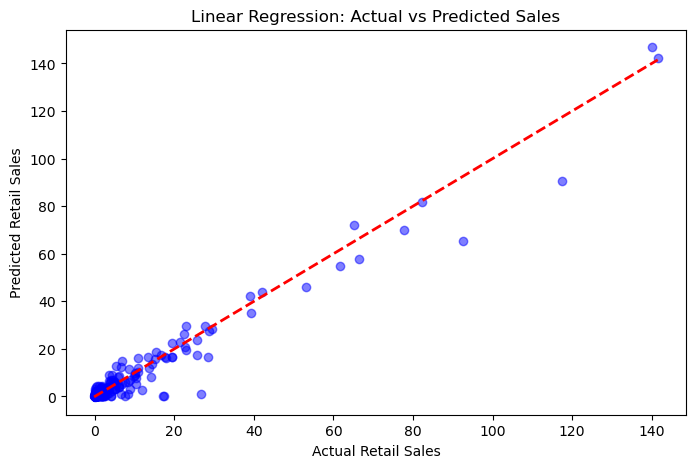

In [22]:
# Initialize Linear Regression Model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R² :", r2_lr)

#Visualizing
plt.figure(figsize=(8,5))
plt.scatter(y_test[:300], y_pred_lr[:300], color='blue', alpha=0.5)
plt.plot([y_test[:300].min(), y_test[:300].max()],
         [y_test[:300].min(), y_test[:300].max()],
         'r--', lw=2)
plt.xlabel("Actual Retail Sales")
plt.ylabel("Predicted Retail Sales")
plt.title("Linear Regression: Actual vs Predicted Sales")
plt.show()

XGBoost Results
MAE: 1.775462763424939
MSE: 78.46486226107922
R²: 0.9132446541535749


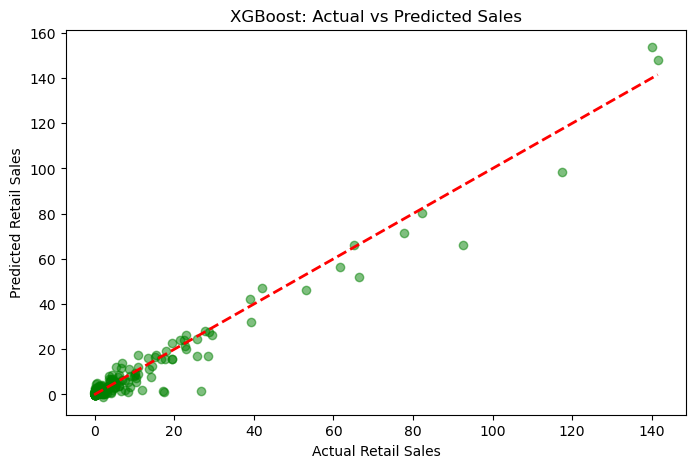

In [26]:
# XGBoost Regression
try:   
 # Initialize model
    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # Train
    xgb_model.fit(X_train, y_train)

    # Predict
    y_pred_xgb = xgb_model.predict(X_test)

    # Evaluate
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)

    print("XGBoost Results")
    print("MAE:", mae_xgb)
    print("MSE:", mse_xgb)
    print("R²:", r2_xgb)

    # Visualization
    plt.figure(figsize=(8,5))
    plt.scatter(y_test[:300], y_pred_xgb[:300], color='green', alpha=0.5)
    plt.plot([y_test[:300].min(), y_test[:300].max()],
             [y_test[:300].min(), y_test[:300].max()],
             'r--', lw=2)
    plt.xlabel("Actual Retail Sales")
    plt.ylabel("Predicted Retail Sales")
    plt.title("XGBoost: Actual vs Predicted Sales")
    plt.show()
except ModuleNotFoundError:
    print("Model not found")

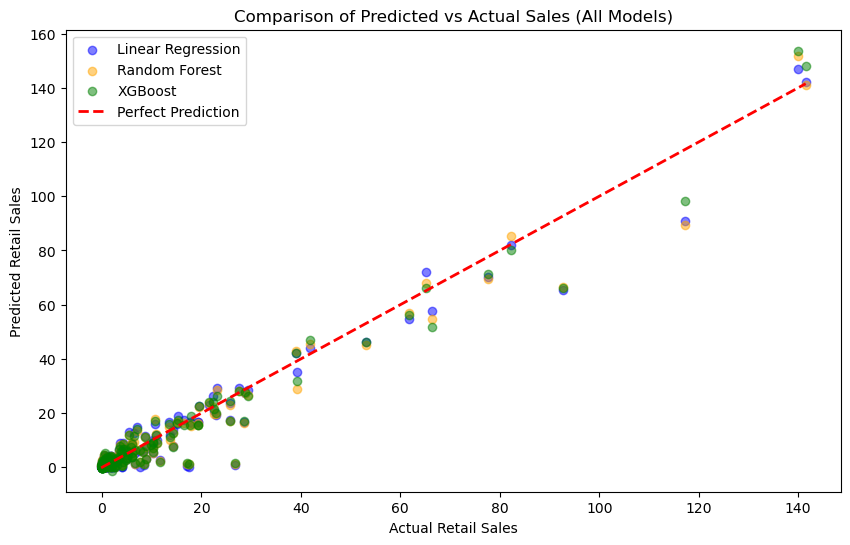

In [28]:
plt.figure(figsize=(10,6))

# Plot 300 points for clarity
n_plot = 300
plt.scatter(y_test[:n_plot], y_pred_lr[:n_plot], color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(y_test[:n_plot], y_pred[:n_plot], color='orange', alpha=0.5, label='Random Forest')
plt.scatter(y_test[:n_plot], y_pred_xgb[:n_plot], color='green', alpha=0.5, label='XGBoost')

# Perfect prediction line
plt.plot([y_test[:n_plot].min(), y_test[:n_plot].max()],
         [y_test[:n_plot].min(), y_test[:n_plot].max()],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual Retail Sales")
plt.ylabel("Predicted Retail Sales")
plt.title("Comparison of Predicted vs Actual Sales (All Models)")
plt.legend()
plt.show()


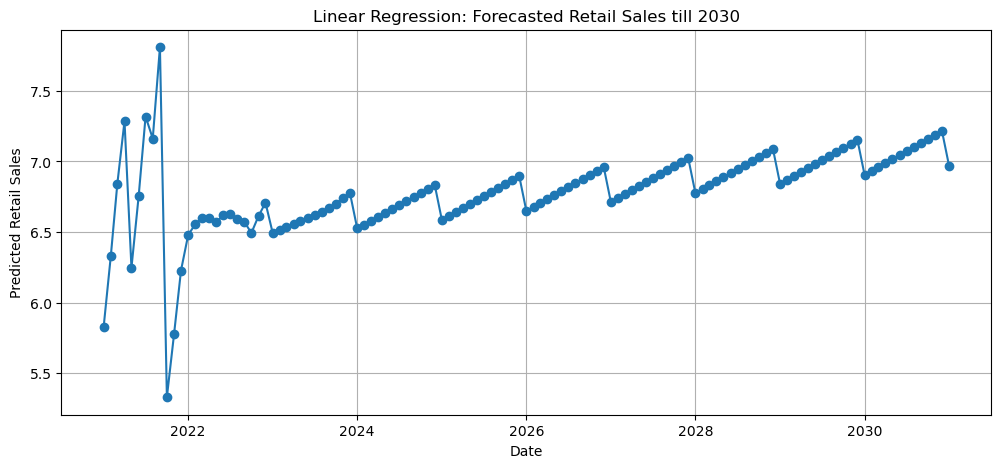

In [30]:
# Forecast Future Sales till 2030 using Linear Regression
last_year = df['YEAR'].max()
last_month = 12
future_months = []
future_years = []

year = last_year
month = last_month + 1
while year <= 2030:
    if month > 12:
        month = 1
        year += 1
    future_years.append(year)
    future_months.append(month)
    month += 1

future_df = pd.DataFrame({
    'YEAR': future_years,
    'MONTH': future_months
})

# To forecast lag features, we will iteratively use previous predictions
# Start with last known sales values
last_sales = df.sort_values(['YEAR','MONTH'])['RETAIL SALES'].tolist()
last_warehouse = df.sort_values(['YEAR','MONTH'])['WAREHOUSE SALES'].tolist()
last_transfers = df.sort_values(['YEAR','MONTH'])['RETAIL TRANSFERS'].tolist()

predictions = []
for i in range(len(future_df)):
    # LAG_1: previous month sales
    lag_1 = last_sales[-1]
    # LAG_12: same month last year, if available
    lag_12 = last_sales[-12] if len(last_sales) >= 12 else last_sales[0]

    # Warehouse and Transfers: use average of last 12 months
    warehouse_avg = np.mean(last_warehouse[-12:])
    transfers_avg = np.mean(last_transfers[-12:])

    X_future = pd.DataFrame({
        'YEAR':[future_df.loc[i,'YEAR']],
        'MONTH':[future_df.loc[i,'MONTH']],
        'WAREHOUSE SALES':[warehouse_avg],
        'RETAIL TRANSFERS':[transfers_avg],
        'RETAIL_SALES_LAG_1':[lag_1],
        'RETAIL_SALES_LAG_12':[lag_12]
    })

    pred = lr_model.predict(X_future)[0]
    predictions.append(pred)
    last_sales.append(pred)
    last_warehouse.append(warehouse_avg)
    last_transfers.append(transfers_avg)

future_df['Predicted_RETAIL_SALES'] = predictions

# Plot forecast
plt.figure(figsize=(12,5))
plt.plot(pd.to_datetime(future_df[['YEAR','MONTH']].assign(DAY=1)), 
         future_df['Predicted_RETAIL_SALES'], marker='o')
plt.xlabel("Date")
plt.ylabel("Predicted Retail Sales")
plt.title("Linear Regression: Forecasted Retail Sales till 2030")
plt.grid(True)
plt.show()

In [ ]:
# Save forecast to CSV
future_df.to_csv("forecasted_retail_sale_2030.csv", index=False)
print("Forecasted sales saved as 'forecasted_retail_sales_2030.csv'")


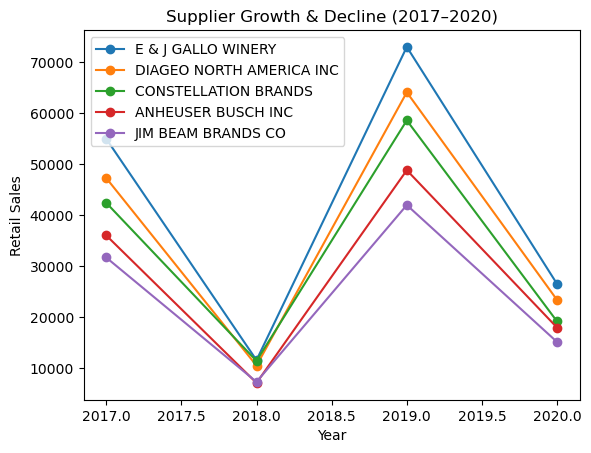

In [32]:
# Supplier Growth & Decline (2017–2020)
supplier_year = (
    df.groupby(['YEAR', 'SUPPLIER'])['RETAIL SALES']
    .sum()
    .reset_index()
)

# top 5 suppliers overall
top_suppliers = (
    df.groupby('SUPPLIER')['RETAIL SALES']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = supplier_year[supplier_year['SUPPLIER'].isin(top_suppliers)]

# plot
for supplier in top_suppliers:
    data = filtered[filtered['SUPPLIER'] == supplier]
    plt.plot(data['YEAR'], data['RETAIL SALES'], marker='o', label=supplier)

plt.xlabel("Year")
plt.ylabel("Retail Sales")
plt.title("Supplier Growth & Decline (2017–2020)")
plt.legend()
plt.show()


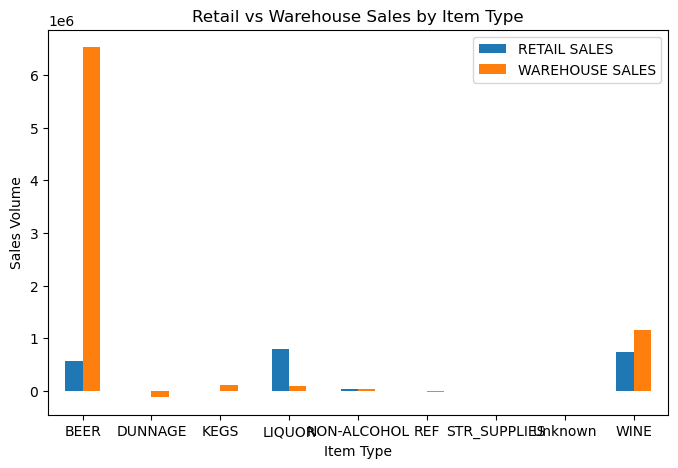

In [34]:
# Retail vs Warehouse Sales by Item Type
category_sales = (
    df.groupby('ITEM TYPE')[['RETAIL SALES', 'WAREHOUSE SALES']]
    .sum()
)

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Retail vs Warehouse Sales by Item Type")
plt.ylabel("Sales Volume")
plt.xlabel("Item Type")
plt.xticks(rotation=0)
plt.show()


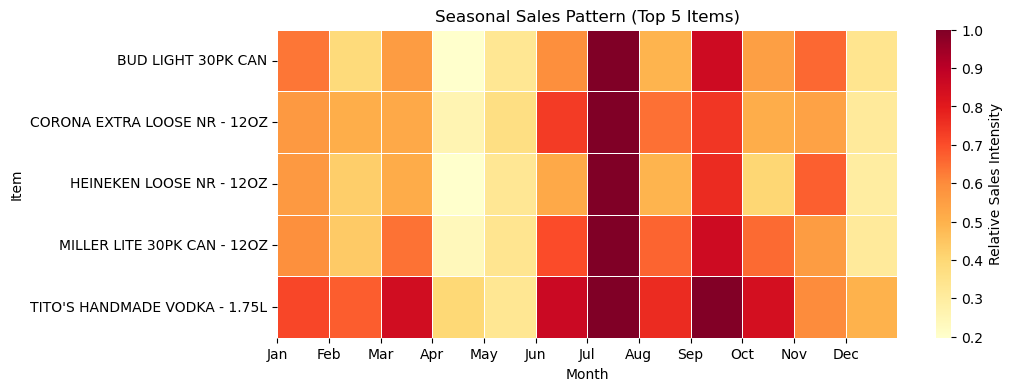

In [36]:
# Seasonal Sales Pattern
import seaborn as sns
top_items = (
    df.groupby('ITEM DESCRIPTION')['RETAIL SALES']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

seasonal_data = df[df['ITEM DESCRIPTION'].isin(top_items)]

monthly_item_sales = (
    seasonal_data.groupby(['MONTH', 'ITEM DESCRIPTION'])['RETAIL SALES']
    .sum()
    .reset_index()
)

pivot_table = monthly_item_sales.pivot(
    index='ITEM DESCRIPTION',
    columns='MONTH',
    values='RETAIL SALES'
)

# normalize rows (pattern-focused)
pivot_norm = pivot_table.div(pivot_table.max(axis=1), axis=0)

plt.figure(figsize=(10,4))
sns.heatmap(
    pivot_norm,
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Relative Sales Intensity'}
)

plt.title("Seasonal Sales Pattern (Top 5 Items)")
plt.xlabel("Month")
plt.ylabel("Item")
plt.xticks(
    ticks=range(12),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.show()
